In [1]:
import random
import torch
import numpy as np

# Set the random seed for reproducibility
seed = 42

# Set random seeds for libraries
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# MiniGPT: A Lightweight Transformer Model  

This implementation defines a simplified GPT-like model using PyTorch, consisting of causal self-attention, feedforward layers, and transformer blocks for autoregressive text generation.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class CausalSelfAttention(nn.Module):
    def __init__(self, seq_len, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv_proj = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.register_buffer("mask", torch.tril(torch.ones(1, 1, seq_len, seq_len)))  # Causal mask

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)   # Project q, k, v together in a batch
        q, k, v = qkv.split(self.embed_dim, dim=2)

        # Reshape dimensions for Multi-head attention
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        attn_weights = (q @ k.transpose(-2, -1)) * math.sqrt(k.shape[-1])

        # Apply causal mask (lower triangular mask)
        causal_mask = torch.tril(torch.ones(T, T, device=x.device)).unsqueeze(0).unsqueeze(0)
        attn_weights = attn_weights.masked_fill(causal_mask == 0, float('-inf'))

        attn_weights = F.softmax(attn_weights, dim=-1)
        attn_output = (attn_weights @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(attn_output)
            
class FeedForward(nn.Module):
    def __init__(self, embed_dim):
        super(FeedForward, self).__init__()
        self.fc1 = nn.Linear(embed_dim, 4 * embed_dim)
        self.fc2 = nn.Linear(4 * embed_dim, embed_dim)
        self.gelu = nn.GELU(approximate='tanh')
    
    def forward(self, x):
        return self.fc2(self.gelu(self.fc1(x)))

class TransformerBlock(nn.Module):
    def __init__(self, seq_len, embed_dim, num_heads):
        super(TransformerBlock, self).__init__()

        self.attention = CausalSelfAttention(seq_len, embed_dim, num_heads)
        self.ln1 = nn.LayerNorm(embed_dim)

        self.feedforward = FeedForward(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = x + self.attention(self.ln1(x))
        x = x + self.feedforward(self.ln2(x))
        return x
    
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, seq_len, embed_dim=768, num_heads=12, num_layers=12):
        super().__init__()
        self.embed_tokens = nn.Embedding(vocab_size, embed_dim)
        self.pos_embeddings = nn.Embedding(seq_len, embed_dim)
        self.layers = nn.ModuleList([TransformerBlock(seq_len, embed_dim, num_heads) for _ in range(num_layers)])
        self.ln_f = nn.LayerNorm(embed_dim)  # Final LayerNorm
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0))  # Causal mask

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.embed_tokens(x) + self.pos_embeddings(pos)

        for layer in self.layers:
            x = layer(x)
        x = self.ln_f(x)
        return self.lm_head(x)  # Logits for each token


# Use a Pretrained GPT-2 Tokenizer  

This code initializes a pre-trained GPT-2 tokenizer.


In [ ]:
from transformers import GPT2TokenizerFast

# Load the pre-trained GPT-2 tokenizer
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

# Add special tokens (if you want to include them, else this step can be skipped)
tokenizer.add_special_tokens({
    "pad_token": "<pad>",
    "bos_token": "<s>",
    "eos_token": "</s>",
    "unk_token": "<unk>"
})

# Tokenize a sample text
sample_text = "Today is a beautyful day"
encoded = tokenizer.encode(sample_text)
decoded = tokenizer.decode(encoded)

print(f"Encoded IDs: {encoded}")
print(f"Decoded text: {decoded}")

# Optionally, save the tokenizer
tokenizer.save_pretrained("gpt2_tokenizer")


Encoded IDs: [8888, 318, 257, 8737, 913, 1110]
Decoded text: Today is a beautyful day


('gpt2_tokenizer\\tokenizer_config.json',
 'gpt2_tokenizer\\special_tokens_map.json',
 'gpt2_tokenizer\\vocab.json',
 'gpt2_tokenizer\\merges.txt',
 'gpt2_tokenizer\\added_tokens.json',
 'gpt2_tokenizer\\tokenizer.json')

# Preparing a Tokenized Dataset for Language Modeling  

This code reads a text file, tokenizes its content using a GPT-2 tokenizer, and creates a PyTorch dataset where each sample consists of a sequence of tokens (`input_ids`) and its corresponding shifted version (`labels`) to train a causal language model.  


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

file_path = "fairytales.txt"

# Read the text file
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

# Tokenize the entire text
tokens = tokenizer.encode(text, add_special_tokens=False)

block_size = 128
class TextDataset(Dataset):
    def __init__(self, tokens, block_size):
        self.tokens = tokens
        self.block_size = block_size

    def __len__(self):
        # Return number of batches (total tokens divided by block size)
        return len(self.tokens) // self.block_size

    def __getitem__(self, idx):
        # Get a chunk of tokens
        start = idx * self.block_size
        end = start + self.block_size
        input_ids = self.tokens[start:end]
        labels = self.tokens[start+1:end+1]  # Shift by one for the labels (next token)

        # Convert the tokens to a tensor
        input_ids = torch.tensor(input_ids, dtype=torch.long)
        labels = torch.tensor(labels, dtype=torch.long)

        return {"input_ids": input_ids, "labels": labels}

Token indices sequence length is longer than the specified maximum sequence length for this model (737268 > 1024). Running this sequence through the model will result in indexing errors


# Training a GPT-like Model with Cosine Learning Rate Scheduling  

This code initializes and trains the MiniGPT model using a tokenized dataset.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  # For loss calculation
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup
from tqdm import tqdm

# Create Dataset and DataLoader
dataset = TextDataset(tokens, block_size)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training with {device}")

# Initialize MiniGPT model
model = MiniGPT(vocab_size=len(tokenizer.get_vocab()),
                seq_len=block_size,
                embed_dim=768,
                num_heads=12,
                num_layers=12).to(device)

# Define optimizer and learning rate scheduler
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

num_epochs = 5
total_iterations = len(dataloader) * num_epochs
warmup_steps = int(0.1 * total_iterations)  # 10% of total steps
scheduler = get_cosine_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=warmup_steps, 
                                            num_training_steps=total_iterations)

# Define loss function (ignores padding tokens)
loss_fn = nn.CrossEntropyLoss()

iteration = 0
running_loss = 0
loss_history = []

print(f"Starting training for {total_iterations} iterations...\n")

# Create a progress bar for tracking iterations
progress_bar = tqdm(total=total_iterations, desc="Training", dynamic_ncols=True)

# Training Loop
for epoch in range(num_epochs):
    for batch in dataloader:
        if iteration >= total_iterations:
            break  # Stop if we reach the total iterations

        model.train()
        input_ids, labels = batch['input_ids'], batch['labels']
        input_ids = input_ids.to(device)  # Shift left for labels
        labels = labels.to(device)  # Align input

        optimizer.zero_grad()
        logits = model(input_ids)  # Forward pass

        # Compute loss (reshape logits & labels)
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        iteration += 1

        # Store loss for plotting
        loss_history.append(loss.item())

        # Update progress bar with loss every step
        avg_loss = running_loss / iteration if iteration > 0 else 0
        progress_bar.set_postfix(loss=f"{avg_loss:.4f}")
        progress_bar.update(1)  # Increment progress bar by 1

progress_bar.close()  # Close progress bar
print("\nTraining complete!")


Training with cuda
Starting training for 3600 iterations...



Training: 100%|██████████| 3600/3600 [05:10<00:00, 11.61it/s, loss=5.5775]


Training complete!


# Visualizing Training Loss Over Iterations  

This code uses Matplotlib and Seaborn to plot the training loss recorded during model training. 

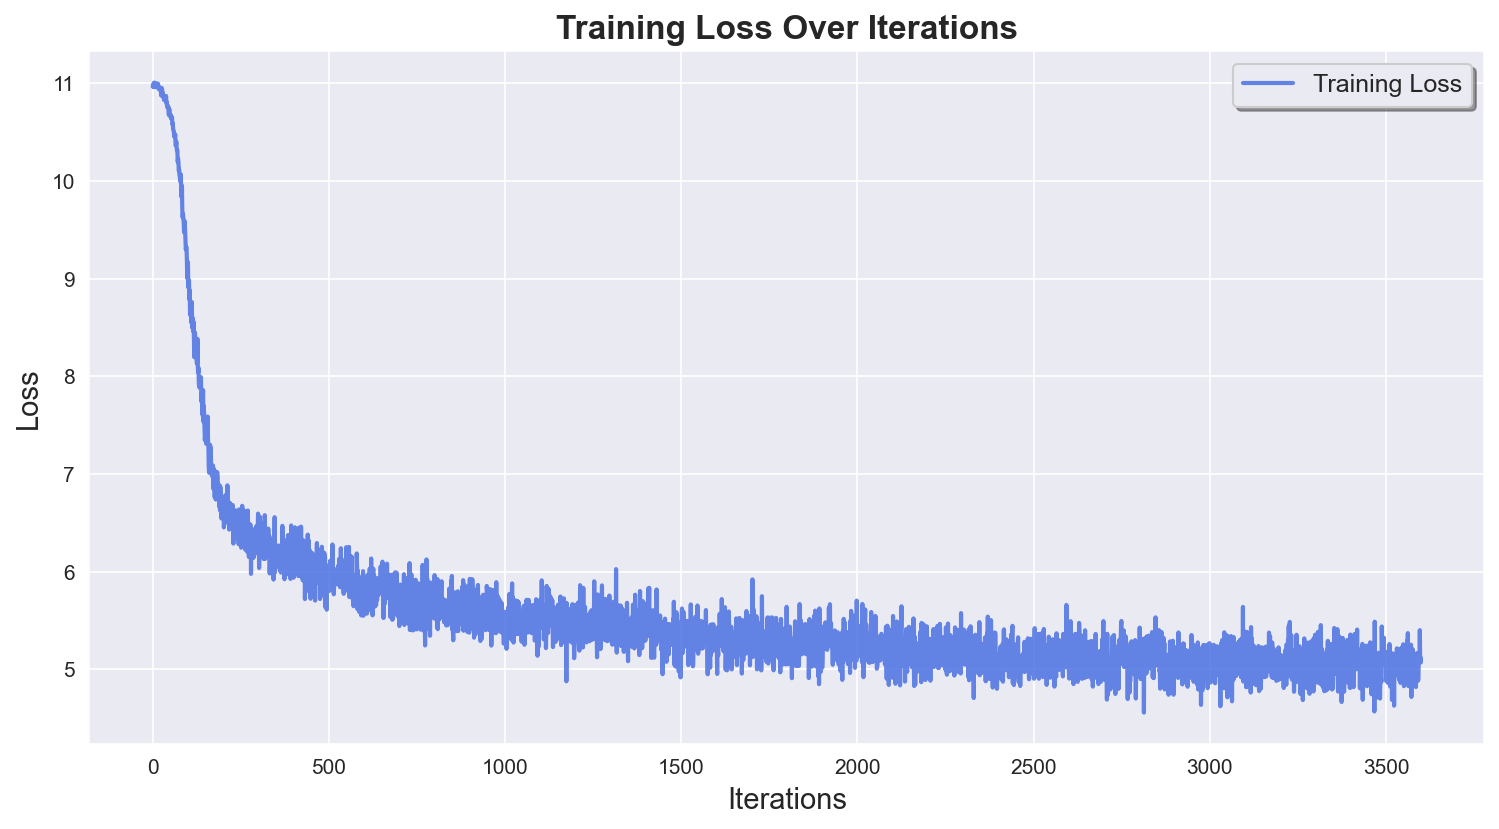

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a beautiful style
sns.set_style("darkgrid")
plt.figure(figsize=(12, 6), dpi=150)  # Increased resolution

# Plot training loss
plt.plot(loss_history, label="Training Loss", color="royalblue", linewidth=2, alpha=0.8)

# Add labels and title with better font sizes
plt.xlabel("Iterations", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.title("Training Loss Over Iterations", fontsize=16, fontweight='bold')

# Customize legend
plt.legend(fontsize=12, loc="upper right", frameon=True, fancybox=True, shadow=True)

# Show the plot
plt.show()


# Text Generation Using a GPT-like Model  

This code defines a `generate_text` function for text generation using a trained GPT-like model.

In [11]:
import torch
import torch.nn.functional as F

# Inference/Generation with custom tokenizer
def generate_text(model, tokenizer, prompt, max_length=100, temperature=1.0):
    model.eval()  # Set the model to evaluation mode
    
    # Encode the input prompt using your custom tokenizer
    encoded = tokenizer.encode(prompt)
    input_ids = torch.tensor([encoded]).to(device)  # Convert to tensor and move to device

    generated = input_ids
    for _ in range(max_length):
        with torch.no_grad():  # No need to track gradients during inference
            logits = model(generated)
            logits = logits[:, -1, :]  # Get the logits for the last token
            
            # Apply temperature (higher values = more randomness)
            logits = logits / temperature
            
            # Sample from the logits (instead of argmax) to allow for diversity
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)  # Sample the next token
            
            generated = torch.cat((generated, next_token), dim=1)  # Append the generated token

            # Optional: Ensure the token is not a special token like <|endoftext|>
            if next_token.item() == tokenizer.encode("<|endoftext|>", add_special_tokens=False)[0]:
                break  # Stop generation if end of text token is produced

    # Decode the generated token sequence back to text, skipping special tokens like `Ċ`
    generated_text = tokenizer.decode(generated[0].cpu().numpy().tolist(), skip_special_tokens=True)

    return generated_text

prompt = "Today is a beautyful day"
generated_text = generate_text(model, tokenizer, prompt, max_length=100, temperature=0.1)

print("\nGenerated Text:")
print(generated_text)



Generated Text:
Today is a beautyful day, and the king's son of the king's son. The old woman was a little, and the king's son was a great man who had been a little man, and the king's daughter, and the old man, and the king's son, and the king's son, and the king's son, and the old man, and the old man, and the king's son of the king's daughter, and the king's son of the king's daughter, and the king's
